# Experiment E1: CoT Truncation Sweep

Plots legibility curves showing how reader accuracy changes as we reveal more of the
generator's chain-of-thought. For each (reader, generator) pair, the reader is crossfilled
with the first N% of the CoT (by character count) and asked to answer.

**Legibility** = the rate at which a reader can answer correctly using the generator's CoT,
with no additional reasoning of its own. If the reader gets the answer wrong given the CoT,
the CoT is illegible at that truncation point.

Datasets: GPQA-Diamond, MATH-500, BBH (6 tasks). All plots include error bars (95% CI).

In [24]:
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from inspect_ai.log import read_eval_log, list_eval_logs

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 100,
})

LOG_DIR = Path.cwd().parent / 'logs' / 'e1_truncation_sweep'
FIGURES_DIR = Path.cwd().parent / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GENERATOR_LABELS = {
    'G1': 'G1 (R1-Distill-Qwen-32B)',
    'G2': 'G2 (DeepSeek-R1)',
    'G3': 'G3 (QwQ-32B)',
}
READER_LABELS = {
    'R1': 'R1 (Qwen3-32B)',
    'R2': 'R2 (Llama-3.1-70B)',
    'R3': 'R3 (DeepSeek-V3)',
    'R5': 'R5 (Gemma-4-31B-IT)',
}
DATASET_LABELS = {
    'gpqa_diamond': 'GPQA-Diamond',
    'math500': 'MATH-500',
    'bbh': 'BBH',
}
GENERATOR_COLORS = {'G1': '#e74c3c', 'G2': '#3498db', 'G3': '#2ecc71'}
READER_COLORS = {'R1': '#e74c3c', 'R2': '#3498db', 'R3': '#9b59b6', 'R5': '#f39c12'}
DATASET_COLORS = {'gpqa_diamond': '#e74c3c', 'math500': '#3498db', 'bbh': '#2ecc71'}

print(f'Log directory: {LOG_DIR}')
print(f'Figures directory: {FIGURES_DIR}')

Log directory: /Users/jackhopkins/PycharmProjects/ReasonMax/experiments/2026/15-4-2026/logs/e1_truncation_sweep
Figures directory: /Users/jackhopkins/PycharmProjects/ReasonMax/experiments/2026/15-4-2026/results/figures


## 1. Load all eval logs (sample-level)

Read full sample-level data from the **non-BBH** eval files (which contain all three
datasets: GPQA-Diamond, MATH-500, BBH). We skip the BBH-only backfill files to
avoid double-counting. Each sample's `dataset` field tells us which benchmark it
belongs to.

In [25]:
log_paths = sorted(LOG_DIR.glob('*.eval'))
print(f'Found {len(log_paths)} total eval files')

# Only read the non-BBH files (the combined ones) to avoid double-counting
# BBH-only files have task names like 'e1_bbh_R1_p10_G1'
sample_rows = []
header_rows = []
load_errors = []

for path in log_paths:
    try:
        log = read_eval_log(str(path), header_only=True)
    except Exception as e:
        load_errors.append((path.name, str(e)))
        continue

    if log.status != 'success':
        load_errors.append((path.name, f'status={log.status}'))
        continue

    task_name = log.eval.task or ''
    is_bbh_only = 'bbh' in task_name

    meta = dict(log.eval.metadata) if log.eval.metadata else {}
    reader_id = meta.get('reader_id', '')
    generator_id = meta.get('generator_id', '')
    truncation_pct = meta.get('truncation_pct')

    if not reader_id or not generator_id or truncation_pct is None:
        load_errors.append((path.name, 'missing metadata'))
        continue

    # Store header-level info for all files (used for coverage check)
    acc_val = None
    se_val = None
    if log.results and log.results.scores:
        for score_obj in log.results.scores:
            if score_obj.metrics:
                for mn, mv in score_obj.metrics.items():
                    v = mv.value if hasattr(mv, 'value') else mv
                    if mn == 'accuracy':
                        acc_val = v
                    elif mn == 'stderr':
                        se_val = v
    header_rows.append({
        'task': task_name, 'reader': reader_id, 'generator': generator_id,
        'pct': int(truncation_pct), 'is_bbh_only': is_bbh_only,
        'accuracy': acc_val, 'stderr': se_val,
        'n_samples': log.results.completed_samples if log.results else 0,
    })

    # Skip BBH-only files for sample-level loading (they duplicate BBH samples
    # already present in the combined files)
    if is_bbh_only:
        continue

    # Full read for sample-level data
    try:
        log_full = read_eval_log(str(path))
    except Exception as e:
        load_errors.append((path.name, f'full read: {e}'))
        continue

    for sample in (log_full.samples or []):
        # Get score value (CORRECT / INCORRECT / NOANSWER)
        correct = False
        sample_dataset = ''
        original_id = ''
        for scorer_name, score in (sample.scores or {}).items():
            correct = (score.value == 'C')  # CORRECT
            smeta = dict(score.metadata) if score.metadata else {}
            sample_dataset = smeta.get('dataset', '')
            original_id = smeta.get('original_sample_id', '')
            break  # only one scorer

        # Fallback to sample metadata if scorer metadata missing
        if not sample_dataset:
            sample_dataset = (sample.metadata or {}).get('dataset', '')
        if not original_id:
            original_id = (sample.metadata or {}).get('original_sample_id', sample.id or '')

        sample_rows.append({
            'sample_id': original_id,
            'dataset': sample_dataset,
            'reader': reader_id,
            'generator': generator_id,
            'pct': int(truncation_pct),
            'correct': int(correct),
            'epoch': (sample.metadata or {}).get('epoch', sample.epoch),
        })

df_samples = pd.DataFrame(sample_rows)
df_headers = pd.DataFrame(header_rows)

print(f'\nSample-level rows: {len(df_samples)}')
print(f'Header-level rows: {len(df_headers)} ({df_headers["is_bbh_only"].sum()} BBH-only)')
print(f'Load errors: {len(load_errors)}')
if load_errors:
    print(f'  First 5: {load_errors[:5]}')

print(f'\nDatasets in samples: {sorted(df_samples["dataset"].unique())}')
print(f'Readers: {sorted(df_samples["reader"].unique())}')
print(f'Generators: {sorted(df_samples["generator"].unique())}')
print(f'Truncation pcts: {sorted(df_samples["pct"].unique())}')
print(f'\nSamples per dataset:')
print(df_samples.groupby('dataset').size().to_string())

Found 240 total eval files

Sample-level rows: 135168
Header-level rows: 240 (108 BBH-only)
Load errors: 0

Datasets in samples: ['bbh', 'gpqa_diamond', 'math500']
Readers: ['R1', 'R2', 'R3', 'R5']
Generators: ['G1', 'G2', 'G3']
Truncation pcts: [np.int64(0), np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100)]

Samples per dataset:
dataset
bbh             65823
gpqa_diamond    22804
math500         46541


## 2. Aggregate: accuracy per (dataset, reader, generator, pct)

Compute accuracy as the mean of per-sample correctness. Also compute a combined
(all datasets) aggregation weighted by sample count.

In [26]:
def compute_accuracy_with_ci(group):
    """Compute accuracy, 95% CI (Wald), and sample count."""
    n = len(group)
    acc = group['correct'].mean()
    se = np.sqrt(acc * (1 - acc) / n) if (0 < acc < 1 and n > 0) else 0.0
    return pd.Series({'accuracy': acc, 'stderr': se, 'n': n})

# Per-dataset accuracy
df_by_ds = (
    df_samples.groupby(['dataset', 'reader', 'generator', 'pct'])
    .apply(compute_accuracy_with_ci, include_groups=False)
    .reset_index()
)

# Combined (all datasets) accuracy
df_combined = (
    df_samples.groupby(['reader', 'generator', 'pct'])
    .apply(compute_accuracy_with_ci, include_groups=False)
    .reset_index()
)

print(f'Per-dataset df shape: {df_by_ds.shape}')
print(f'Combined df shape: {df_combined.shape}')
print(f'\nDataset sample counts (total across all combos):')
print(df_by_ds.groupby('dataset')['n'].sum().to_string())

Per-dataset df shape: (396, 7)
Combined df shape: (132, 6)

Dataset sample counts (total across all combos):
dataset
bbh             65823.0
gpqa_diamond    22804.0
math500         46541.0


## 3. Per-Generator Truncation Curves (averaged across readers)

Main result: shows how legibility (reader accuracy) accumulates across the CoT for each generator.
Each line is one generator, averaged across all 4 readers.

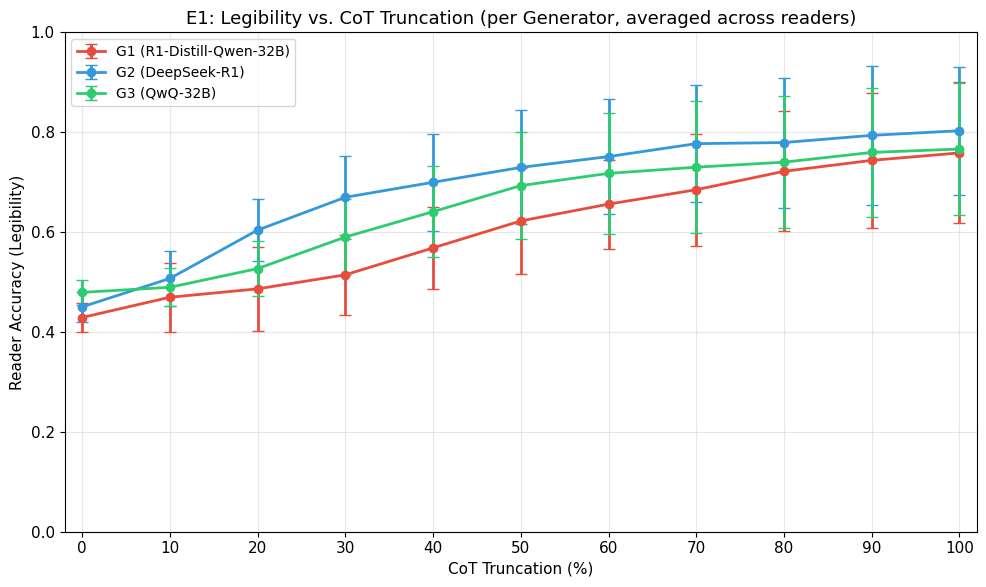


Per-generator accuracy at key truncation points:
  G1 @   0%: 0.429
  G1 @  30%: 0.514
  G1 @  50%: 0.622
  G1 @  70%: 0.685
  G1 @ 100%: 0.759
  G2 @   0%: 0.450
  G2 @  30%: 0.670
  G2 @  50%: 0.729
  G2 @  70%: 0.777
  G2 @ 100%: 0.803
  G3 @   0%: 0.479
  G3 @  30%: 0.590
  G3 @  50%: 0.693
  G3 @  70%: 0.730
  G3 @ 100%: 0.766


In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

for gid in ['G1', 'G2', 'G3']:
    gdata = df_combined[df_combined['generator'] == gid]
    if gdata.empty:
        continue

    agg = gdata.groupby('pct').agg(
        mean_acc=('accuracy', 'mean'),
        sem_acc=('accuracy', lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0),
        n_readers=('accuracy', 'count'),
    ).reset_index().sort_values('pct')

    pcts = agg['pct'].values
    means = agg['mean_acc'].values
    ci95 = 1.96 * agg['sem_acc'].values

    ax.errorbar(pcts, means, yerr=ci95, fmt='o-', capsize=4, linewidth=2,
                markersize=6, label=GENERATOR_LABELS[gid], color=GENERATOR_COLORS[gid])

ax.set_xlabel('CoT Truncation (%)')
ax.set_ylabel('Reader Accuracy (Legibility)')
ax.set_title('E1: Legibility vs. CoT Truncation (per Generator, averaged across readers)')
ax.set_xticks(range(0, 110, 10))
ax.set_xlim(-2, 102)
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(str(FIGURES_DIR / 'e1_truncation_per_generator.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-generator accuracy at key truncation points:')
for gid in ['G1', 'G2', 'G3']:
    gdata = df_combined[df_combined['generator'] == gid]
    for pct in [0, 30, 50, 70, 100]:
        row = gdata[gdata['pct'] == pct]
        if not row.empty:
            acc = row['accuracy'].mean()
            print(f'  {gid} @ {pct:3d}%: {acc:.3f}')

## 4. Per-Reader Truncation Curves (averaged across generators)

Shows how different readers benefit from additional CoT. Each line is one reader,
averaged across all 3 generators.

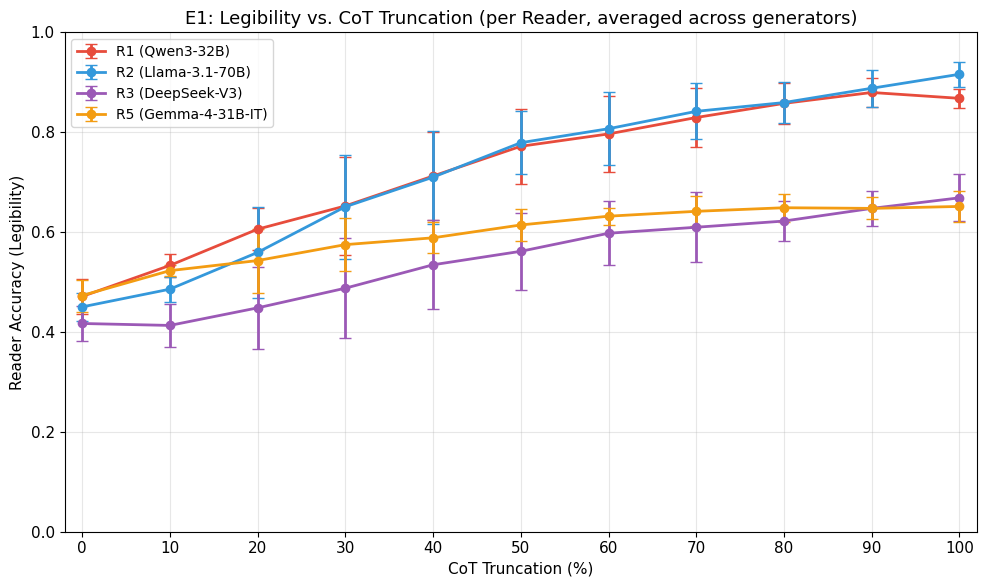

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

for rid in ['R1', 'R2', 'R3', 'R5']:
    rdata = df_combined[df_combined['reader'] == rid]
    if rdata.empty:
        continue

    agg = rdata.groupby('pct').agg(
        mean_acc=('accuracy', 'mean'),
        sem_acc=('accuracy', lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0),
    ).reset_index().sort_values('pct')

    pcts = agg['pct'].values
    means = agg['mean_acc'].values
    ci95 = 1.96 * agg['sem_acc'].values

    ax.errorbar(pcts, means, yerr=ci95, fmt='o-', capsize=4, linewidth=2,
                markersize=6, label=READER_LABELS[rid], color=READER_COLORS[rid])

ax.set_xlabel('CoT Truncation (%)')
ax.set_ylabel('Reader Accuracy (Legibility)')
ax.set_title('E1: Legibility vs. CoT Truncation (per Reader, averaged across generators)')
ax.set_xticks(range(0, 110, 10))
ax.set_xlim(-2, 102)
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(str(FIGURES_DIR / 'e1_truncation_per_reader.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Full Grid: Reader x Generator Faceted Plots

One subplot per reader, showing all 3 generator curves. This is the most detailed view.

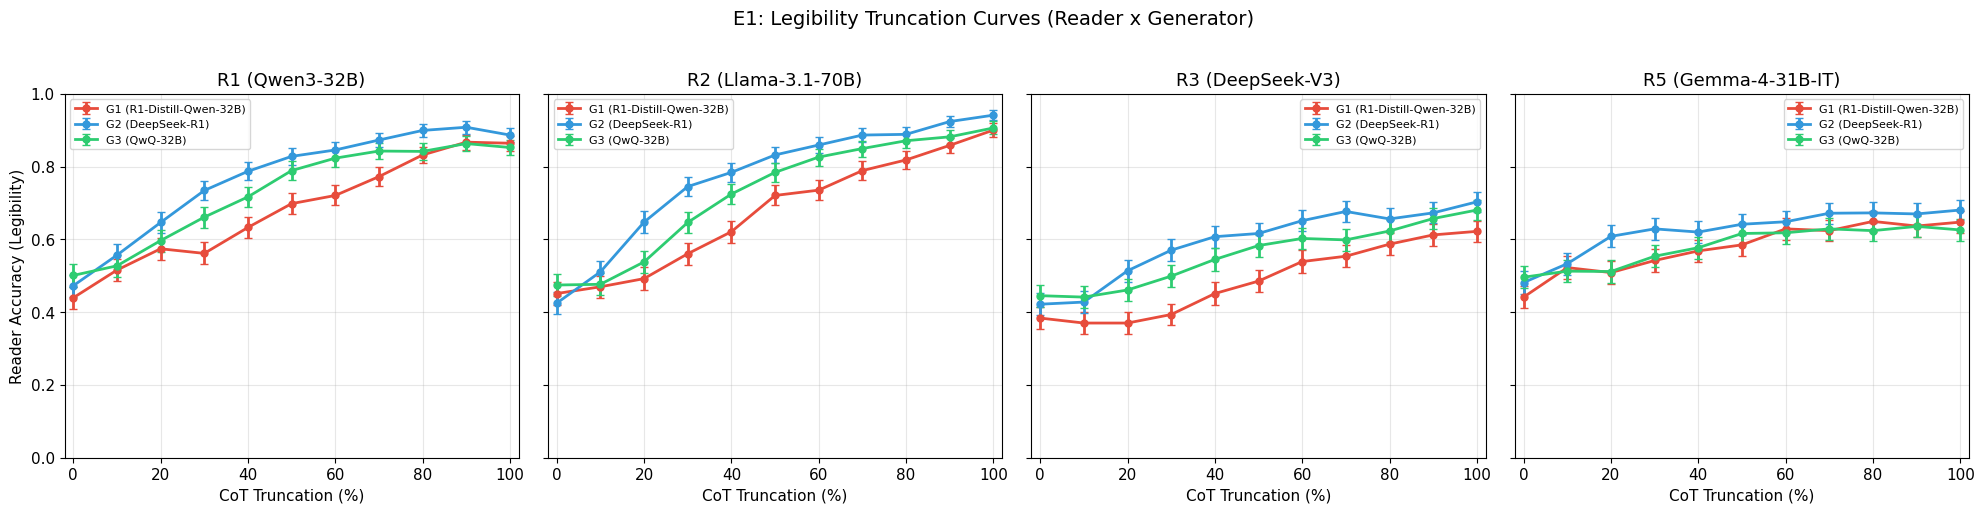

In [29]:
readers = sorted(df_combined['reader'].unique())
n_readers = len(readers)
fig, axes = plt.subplots(1, n_readers, figsize=(5 * n_readers, 5), sharey=True)
if n_readers == 1:
    axes = [axes]

for ax, rid in zip(axes, readers):
    rdata = df_combined[df_combined['reader'] == rid]

    for gid in ['G1', 'G2', 'G3']:
        gdata = rdata[rdata['generator'] == gid].sort_values('pct')
        if gdata.empty:
            continue

        pcts = gdata['pct'].values
        accs = gdata['accuracy'].values
        ci95 = 1.96 * gdata['stderr'].values

        ax.errorbar(pcts, accs, yerr=ci95, fmt='o-', capsize=3, linewidth=2,
                    markersize=5, label=GENERATOR_LABELS[gid], color=GENERATOR_COLORS[gid])

    ax.set_xlabel('CoT Truncation (%)')
    if rid == readers[0]:
        ax.set_ylabel('Reader Accuracy (Legibility)')
    ax.set_title(READER_LABELS[rid])
    ax.set_xticks(range(0, 110, 20))
    ax.set_xlim(-2, 102)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('E1: Legibility Truncation Curves (Reader x Generator)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(str(FIGURES_DIR / 'e1_truncation_faceted.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Dataset Comparison: GPQA-Diamond vs MATH-500 vs BBH

Split by dataset to check whether the truncation pattern differs across task types.

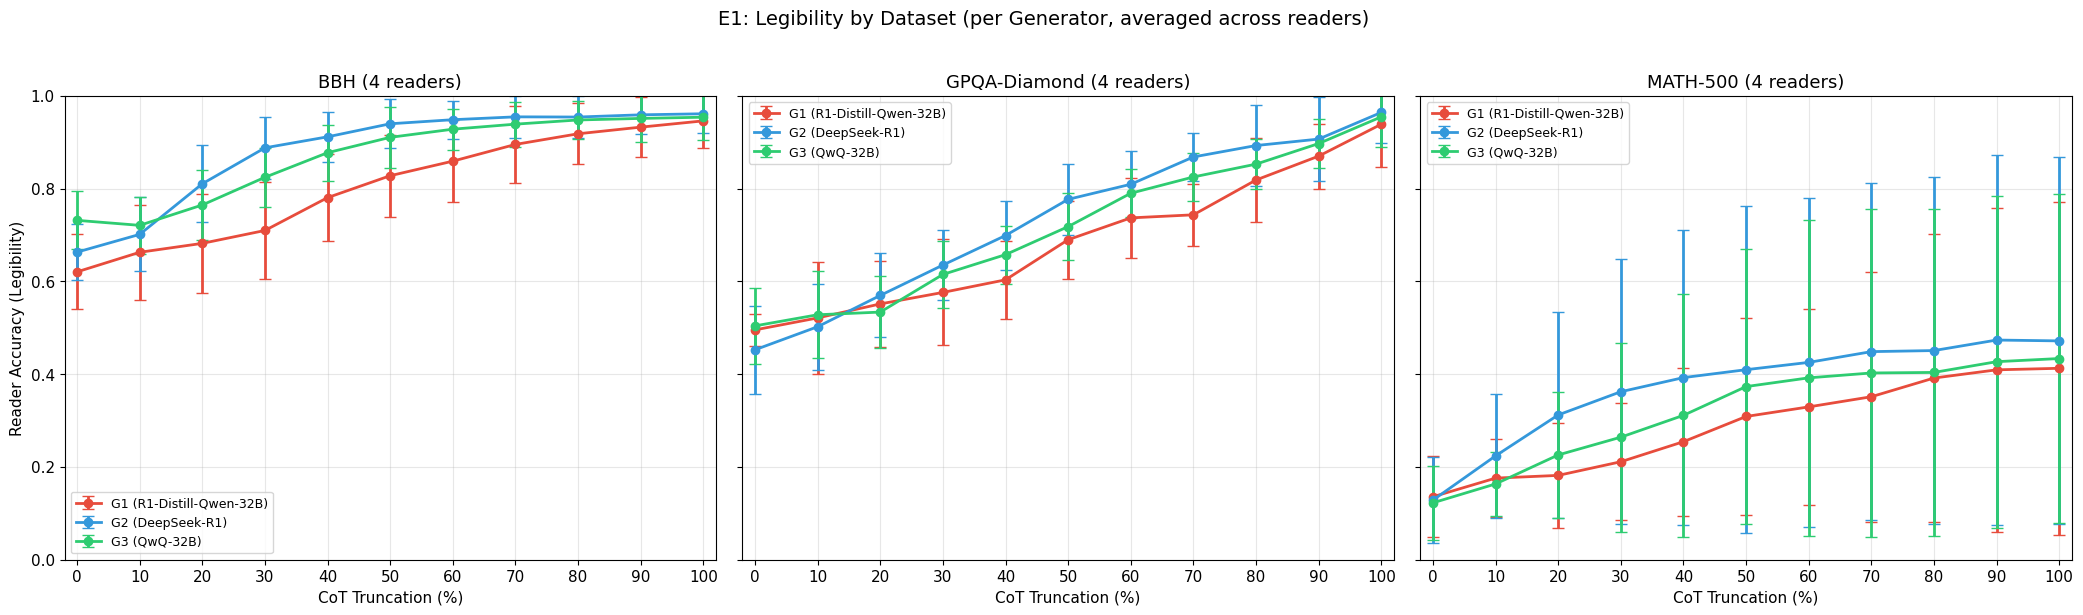

In [30]:
datasets = sorted(df_by_ds['dataset'].unique())
n_ds = len(datasets)
fig, axes = plt.subplots(1, n_ds, figsize=(7 * n_ds, 6), sharey=True)
if n_ds == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    ds_data = df_by_ds[df_by_ds['dataset'] == ds]

    for gid in ['G1', 'G2', 'G3']:
        gdata = ds_data[ds_data['generator'] == gid]
        if gdata.empty:
            continue

        agg = gdata.groupby('pct').agg(
            mean_acc=('accuracy', 'mean'),
            sem_acc=('accuracy', lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0),
        ).reset_index().sort_values('pct')

        pcts = agg['pct'].values
        means = agg['mean_acc'].values
        ci95 = 1.96 * agg['sem_acc'].values

        ax.errorbar(pcts, means, yerr=ci95, fmt='o-', capsize=4, linewidth=2,
                    markersize=6, label=GENERATOR_LABELS[gid], color=GENERATOR_COLORS[gid])

    ax.set_xlabel('CoT Truncation (%)')
    if ds == datasets[0]:
        ax.set_ylabel('Reader Accuracy (Legibility)')
    n_readers_ds = len(ds_data['reader'].unique())
    ax.set_title(f'{DATASET_LABELS.get(ds, ds)} ({n_readers_ds} readers)')
    ax.set_xticks(range(0, 110, 10))
    ax.set_xlim(-2, 102)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('E1: Legibility by Dataset (per Generator, averaged across readers)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(str(FIGURES_DIR / 'e1_truncation_by_dataset.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Heatmap: Accuracy at full CoT (100%) per (Reader, Generator)

Shows the final legibility rate for each reader-generator pair.

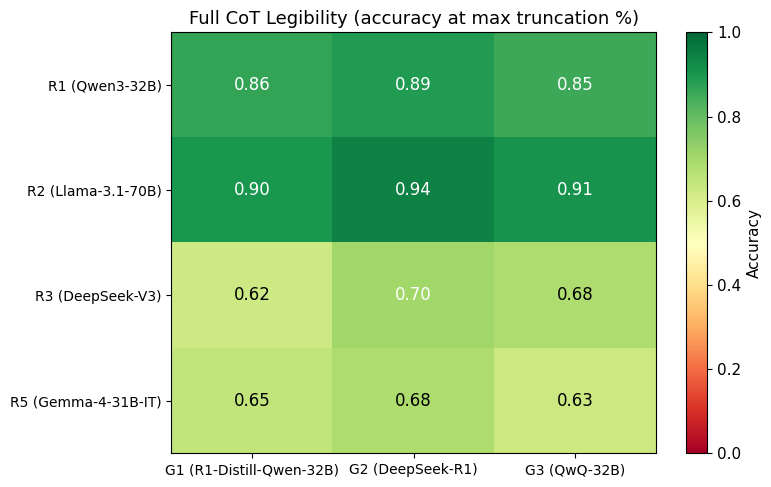

In [31]:
full_data = df_combined.loc[df_combined.groupby(['reader', 'generator'])['pct'].idxmax()]

readers_sorted = sorted(full_data['reader'].unique())
generators_sorted = sorted(full_data['generator'].unique())

matrix = np.full((len(readers_sorted), len(generators_sorted)), np.nan)
for _, row in full_data.iterrows():
    i = readers_sorted.index(row['reader'])
    j = generators_sorted.index(row['generator'])
    matrix[i, j] = row['accuracy']

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(generators_sorted)))
ax.set_yticks(range(len(readers_sorted)))
ax.set_xticklabels([GENERATOR_LABELS.get(g, g) for g in generators_sorted], fontsize=10)
ax.set_yticklabels([READER_LABELS.get(r, r) for r in readers_sorted], fontsize=10)
ax.set_title('Full CoT Legibility (accuracy at max truncation %)')

for i in range(len(readers_sorted)):
    for j in range(len(generators_sorted)):
        val = matrix[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=12,
                    color='black' if 0.3 < val < 0.7 else 'white')

plt.colorbar(im, ax=ax, label='Accuracy')
fig.tight_layout()
fig.savefig(str(FIGURES_DIR / 'e1_legibility_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Legibility Delta (C2 - C4 proxy)

The legibility delta at each truncation point is the C2 pass rate (accuracy at pct)
minus the p=0% baseline (no CoT at all). This controls for the reader's baseline
capability and isolates the information gain from each additional segment of the CoT.

Per SPEC: "The legibility delta at each truncation point is C2 pass rate minus the
C4 (no-CoT) baseline for that reader."

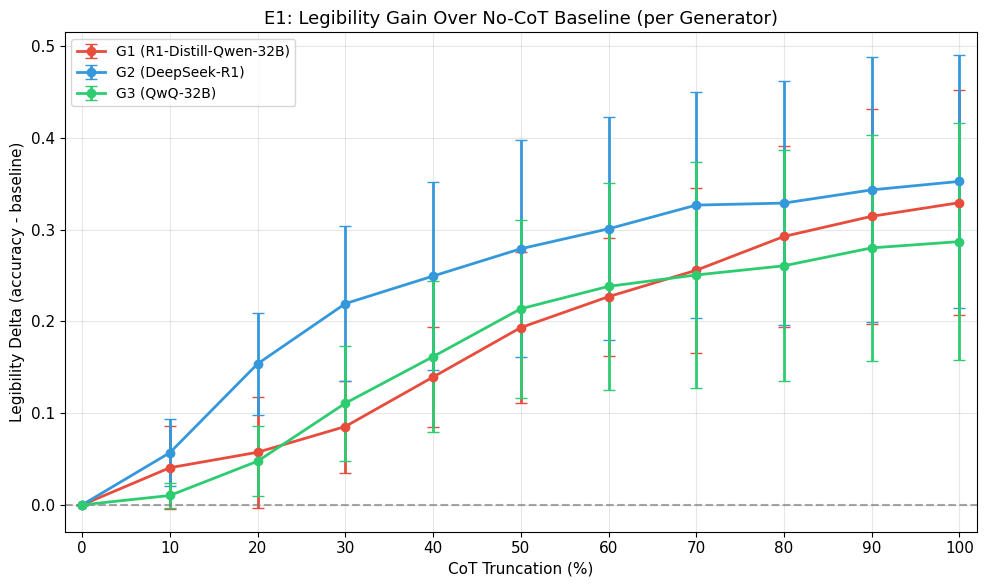


Truncation point where legibility delta first exceeds 5pp:
  G1: 20% (delta = 0.057)
  G2: 10% (delta = 0.057)
  G3: 30% (delta = 0.111)


In [32]:
baselines = df_combined[df_combined['pct'] == 0].set_index(['reader', 'generator'])['accuracy']

fig, ax = plt.subplots(figsize=(10, 6))

for gid in ['G1', 'G2', 'G3']:
    gdata = df_combined[df_combined['generator'] == gid]

    deltas_by_pct = defaultdict(list)
    for _, row in gdata.iterrows():
        key = (row['reader'], row['generator'])
        if key in baselines.index:
            delta = row['accuracy'] - baselines.loc[key]
            deltas_by_pct[row['pct']].append(delta)

    pcts = sorted(deltas_by_pct.keys())
    means = [np.mean(deltas_by_pct[p]) for p in pcts]
    sems = [np.std(deltas_by_pct[p], ddof=1) / np.sqrt(len(deltas_by_pct[p]))
            if len(deltas_by_pct[p]) > 1 else 0 for p in pcts]
    ci95 = [1.96 * s for s in sems]

    ax.errorbar(pcts, means, yerr=ci95, fmt='o-', capsize=4, linewidth=2,
                markersize=6, label=GENERATOR_LABELS[gid], color=GENERATOR_COLORS[gid])

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('CoT Truncation (%)')
ax.set_ylabel('Legibility Delta (accuracy - baseline)')
ax.set_title('E1: Legibility Gain Over No-CoT Baseline (per Generator)')
ax.set_xticks(range(0, 110, 10))
ax.set_xlim(-2, 102)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(str(FIGURES_DIR / 'e1_truncation_delta.png'), dpi=150, bbox_inches='tight')
plt.show()

# Report the truncation point at which delta first exceeds 5pp
print('\nTruncation point where legibility delta first exceeds 5pp:')
for gid in ['G1', 'G2', 'G3']:
    gdata = df_combined[df_combined['generator'] == gid]
    deltas_by_pct = defaultdict(list)
    for _, row in gdata.iterrows():
        key = (row['reader'], row['generator'])
        if key in baselines.index:
            delta = row['accuracy'] - baselines.loc[key]
            deltas_by_pct[row['pct']].append(delta)

    for p in sorted(deltas_by_pct.keys()):
        mean_delta = np.mean(deltas_by_pct[p])
        if mean_delta > 0.05:
            print(f'  {gid}: {p}% (delta = {mean_delta:.3f})')
            break
    else:
        print(f'  {gid}: never exceeds 5pp')

## 9. Legibility Delta on Hard Samples (wrong at 0%, right at 100%)

The most informative samples are those where the reader **fails without the CoT** (p=0%)
but **succeeds with the full CoT** (p=100%). These are the samples where the CoT is
genuinely necessary and sufficient -- the reader cannot answer on its own, but the
generator's reasoning makes the answer accessible.

By restricting to these samples, we remove:
- Easy questions the reader already knows (right at 0%) -- no signal about CoT usefulness
- Hopeless questions (wrong at both 0% and 100%) -- CoT is truly illegible

This isolates the **pure legibility signal**: how does accuracy on these hard-but-solvable
samples accumulate as we reveal more of the CoT?

In [33]:
# Identify hard samples: wrong at p=0, correct at p=100 (or max available pct)
# A sample is identified by (sample_id, reader, generator, epoch)

max_pct = df_samples['pct'].max()
sample_key_cols = ['sample_id', 'reader', 'generator', 'epoch']

# Get correctness at p=0
at_0 = df_samples[df_samples['pct'] == 0][sample_key_cols + ['correct']].copy()
at_0 = at_0.rename(columns={'correct': 'correct_at_0'})

# Get correctness at max pct (100%)
at_max = df_samples[df_samples['pct'] == max_pct][sample_key_cols + ['correct']].copy()
at_max = at_max.rename(columns={'correct': 'correct_at_max'})

# Merge to find samples present at both endpoints
endpoints = at_0.merge(at_max, on=sample_key_cols, how='inner')

# Hard samples: wrong at 0%, right at 100%
hard_keys = endpoints[
    (endpoints['correct_at_0'] == 0) & (endpoints['correct_at_max'] == 1)
][sample_key_cols]

# Tag all sample rows that match a hard sample key
df_hard = df_samples.merge(hard_keys, on=sample_key_cols, how='inner')

# Also get the complement: wrong at 0%, wrong at 100% (hopeless)
hopeless_keys = endpoints[
    (endpoints['correct_at_0'] == 0) & (endpoints['correct_at_max'] == 0)
][sample_key_cols]

n_total = len(endpoints)
n_easy = len(endpoints[endpoints['correct_at_0'] == 1])
n_hard = len(hard_keys)
n_hopeless = len(hopeless_keys)

print(f'Total samples with both p=0 and p={max_pct}: {n_total}')
print(f'  Easy (correct at p=0):                      {n_easy} ({n_easy/n_total:.1%})')
print(f'  Hard (wrong at p=0, correct at p={max_pct}):  {n_hard} ({n_hard/n_total:.1%})')
print(f'  Hopeless (wrong at both):                   {n_hopeless} ({n_hopeless/n_total:.1%})')
print(f'\nHard samples per generator:')
print(hard_keys.groupby('generator').size().to_string())
print(f'\nHard sample rows across all truncation points: {len(df_hard)}')

Total samples with both p=0 and p=100: 5522
  Easy (correct at p=0):                      2505 (45.4%)
  Hard (wrong at p=0, correct at p=100):  1917 (34.7%)
  Hopeless (wrong at both):                   1100 (19.9%)

Hard samples per generator:
generator
G1    671
G2    683
G3    563

Hard sample rows across all truncation points: 11612


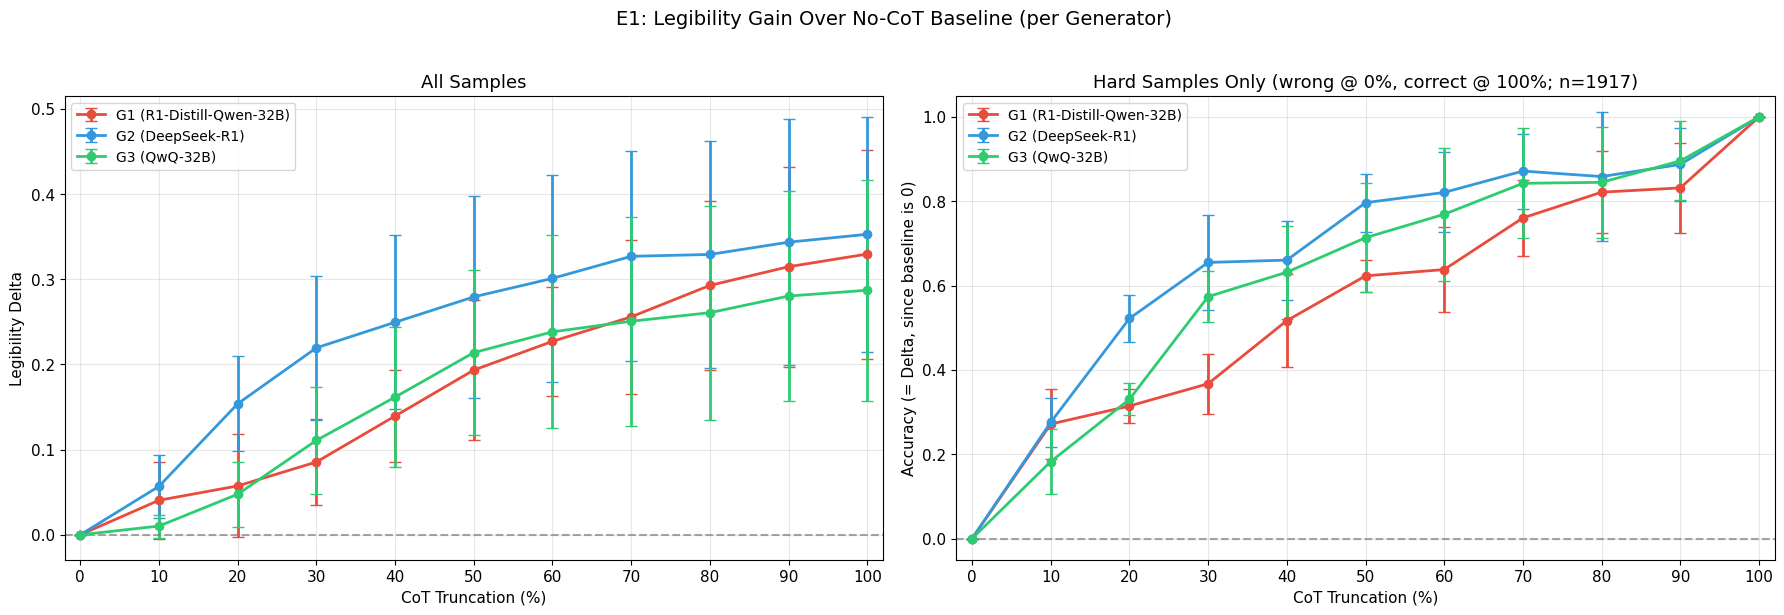


Hard samples: truncation point where accuracy first exceeds 25%:
  G1: 10% (accuracy = 0.272)
  G2: 10% (accuracy = 0.276)
  G3: 20% (accuracy = 0.330)


In [34]:
# Aggregate hard samples: accuracy per (reader, generator, pct)
df_hard_agg = (
    df_hard.groupby(['reader', 'generator', 'pct'])
    .apply(compute_accuracy_with_ci, include_groups=False)
    .reset_index()
)

# Baseline for hard samples is 0 by definition (all wrong at p=0),
# so accuracy == delta. But we plot it as a delta chart for consistency.

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: All samples delta (same as section 8)
ax = axes[0]
baselines_all = df_combined[df_combined['pct'] == 0].set_index(['reader', 'generator'])['accuracy']
for gid in ['G1', 'G2', 'G3']:
    gdata = df_combined[df_combined['generator'] == gid]
    deltas_by_pct = defaultdict(list)
    for _, row in gdata.iterrows():
        key = (row['reader'], row['generator'])
        if key in baselines_all.index:
            deltas_by_pct[row['pct']].append(row['accuracy'] - baselines_all.loc[key])
    pcts = sorted(deltas_by_pct.keys())
    means = [np.mean(deltas_by_pct[p]) for p in pcts]
    sems = [np.std(deltas_by_pct[p], ddof=1) / np.sqrt(len(deltas_by_pct[p]))
            if len(deltas_by_pct[p]) > 1 else 0 for p in pcts]
    ax.errorbar(pcts, means, yerr=[1.96 * s for s in sems], fmt='o-', capsize=4,
                linewidth=2, markersize=6, label=GENERATOR_LABELS[gid],
                color=GENERATOR_COLORS[gid])
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('CoT Truncation (%)')
ax.set_ylabel('Legibility Delta')
ax.set_title('All Samples')
ax.set_xticks(range(0, 110, 10))
ax.set_xlim(-2, 102)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: Hard samples only (wrong at 0%, correct at 100%)
ax = axes[1]
for gid in ['G1', 'G2', 'G3']:
    gdata = df_hard_agg[df_hard_agg['generator'] == gid]
    if gdata.empty:
        continue

    # For hard samples, baseline accuracy is 0 (all wrong at p=0),
    # so accuracy IS the delta
    agg = gdata.groupby('pct').agg(
        mean_acc=('accuracy', 'mean'),
        sem_acc=('accuracy', lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0),
    ).reset_index().sort_values('pct')

    pcts = agg['pct'].values
    means = agg['mean_acc'].values
    ci95 = 1.96 * agg['sem_acc'].values

    ax.errorbar(pcts, means, yerr=ci95, fmt='o-', capsize=4, linewidth=2,
                markersize=6, label=GENERATOR_LABELS[gid], color=GENERATOR_COLORS[gid])

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('CoT Truncation (%)')
ax.set_ylabel('Accuracy (= Delta, since baseline is 0)')
ax.set_title(f'Hard Samples Only (wrong @ 0%, correct @ {max_pct}%; n={n_hard})')
ax.set_xticks(range(0, 110, 10))
ax.set_xlim(-2, 102)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

fig.suptitle('E1: Legibility Gain Over No-CoT Baseline (per Generator)', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(str(FIGURES_DIR / 'e1_truncation_delta_hard.png'), dpi=150, bbox_inches='tight')
plt.show()

# Report threshold crossings for hard samples
print('\nHard samples: truncation point where accuracy first exceeds 25%:')
for gid in ['G1', 'G2', 'G3']:
    gdata = df_hard_agg[df_hard_agg['generator'] == gid]
    agg = gdata.groupby('pct')['accuracy'].mean().sort_index()
    for p, acc in agg.items():
        if acc > 0.25:
            print(f'  {gid}: {p}% (accuracy = {acc:.3f})')
            break
    else:
        print(f'  {gid}: never exceeds 25%')

## 10. Hard Samples: Per-Reader Breakdown

Same hard-sample analysis, but faceted by reader to see which readers are best
at extracting reasoning from partial CoTs.

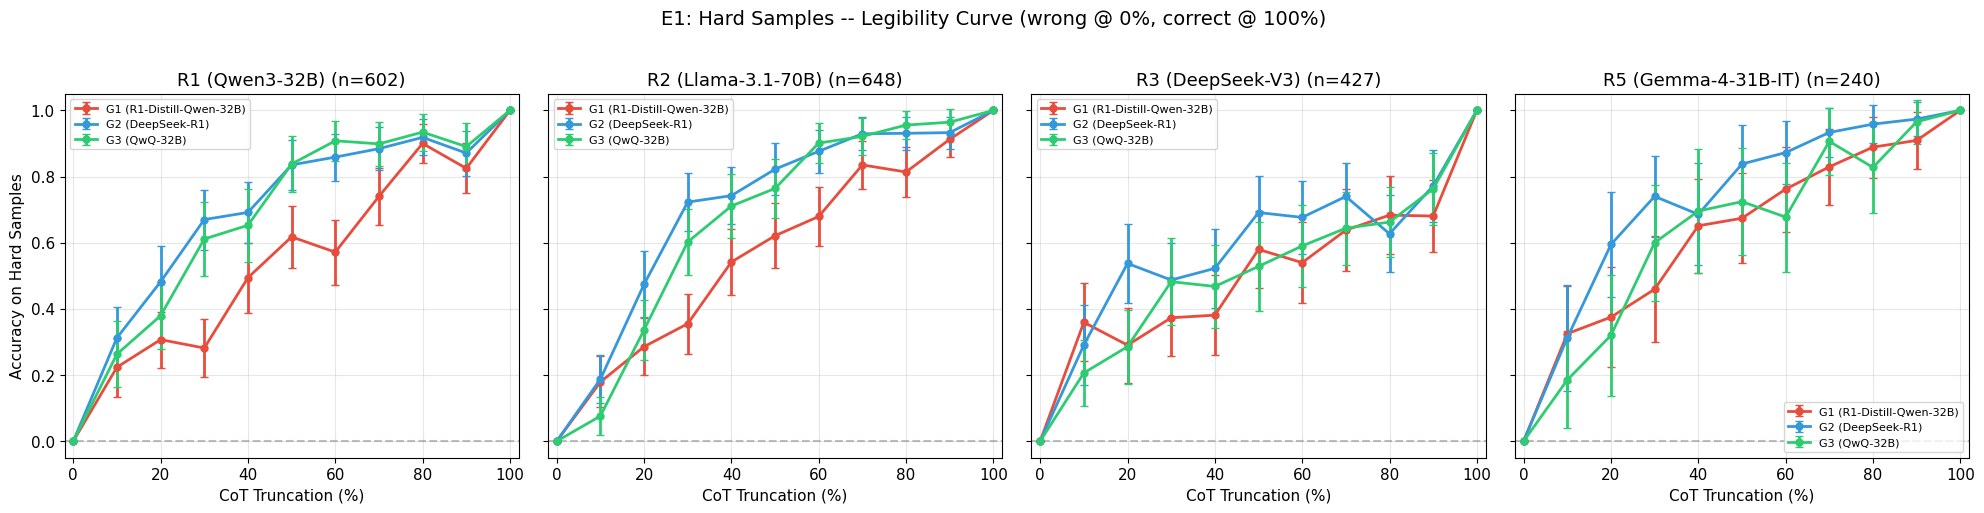

In [35]:
readers = sorted(df_hard_agg['reader'].unique())
n_readers = len(readers)
if n_readers == 0:
    print('No hard sample data available')
else:
    fig, axes = plt.subplots(1, n_readers, figsize=(5 * n_readers, 5), sharey=True)
    if n_readers == 1:
        axes = [axes]

    for ax, rid in zip(axes, readers):
        rdata = df_hard_agg[df_hard_agg['reader'] == rid]

        for gid in ['G1', 'G2', 'G3']:
            gdata = rdata[rdata['generator'] == gid].sort_values('pct')
            if gdata.empty:
                continue
            pcts = gdata['pct'].values
            accs = gdata['accuracy'].values
            ci95 = 1.96 * gdata['stderr'].values
            ax.errorbar(pcts, accs, yerr=ci95, fmt='o-', capsize=3, linewidth=2,
                        markersize=5, label=GENERATOR_LABELS[gid], color=GENERATOR_COLORS[gid])

        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xlabel('CoT Truncation (%)')
        if rid == readers[0]:
            ax.set_ylabel('Accuracy on Hard Samples')
        # Count hard samples for this reader
        n_hard_r = len(df_hard[(df_hard['reader'] == rid) & (df_hard['pct'] == 0)])
        ax.set_title(f'{READER_LABELS[rid]} (n={n_hard_r})')
        ax.set_xticks(range(0, 110, 20))
        ax.set_xlim(-2, 102)
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle(f'E1: Hard Samples -- Legibility Curve (wrong @ 0%, correct @ {max_pct}%)',
                 fontsize=14, y=1.02)
    fig.tight_layout()
    fig.savefig(str(FIGURES_DIR / 'e1_truncation_hard_per_reader.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 11. Summary Table

In [36]:
print('=' * 75)
print('E1 TRUNCATION SWEEP SUMMARY')
print('=' * 75)
print(f'Total sample-level rows: {len(df_samples)}')
print(f'Datasets: {sorted(df_samples["dataset"].unique())}')
print(f'Readers: {sorted(df_samples["reader"].unique())}')
print(f'Generators: {sorted(df_samples["generator"].unique())}')
print(f'Truncation points: {sorted(df_samples["pct"].unique())}')
print()

print('Samples per dataset:')
for ds in sorted(df_samples['dataset'].unique()):
    n = len(df_samples[df_samples['dataset'] == ds])
    print(f'  {DATASET_LABELS.get(ds, ds)}: {n}')
print()

print('Accuracy at 0% (no CoT) vs full CoT (per generator, avg across readers):')
for gid in ['G1', 'G2', 'G3']:
    gdata = df_combined[df_combined['generator'] == gid]
    acc_0 = gdata[gdata['pct'] == 0]['accuracy'].mean()
    acc_full = gdata[gdata['pct'] == max_pct]['accuracy'].mean()
    print(f'  {GENERATOR_LABELS[gid]}: {acc_0:.3f} -> {acc_full:.3f} (gain: {acc_full - acc_0:+.3f})')

print()
print('Accuracy at 0% vs full CoT (per reader, avg across generators):')
for rid in ['R1', 'R2', 'R3', 'R5']:
    rdata = df_combined[df_combined['reader'] == rid]
    if rdata.empty:
        continue
    acc_0 = rdata[rdata['pct'] == 0]['accuracy'].mean()
    acc_full = rdata[rdata['pct'] == max_pct]['accuracy'].mean()
    print(f'  {READER_LABELS[rid]}: {acc_0:.3f} -> {acc_full:.3f} (gain: {acc_full - acc_0:+.3f})')

print()
print(f'Hard sample analysis (wrong @ 0%, correct @ {max_pct}%):')
print(f'  Total hard samples: {n_hard} / {n_total} ({n_hard/n_total:.1%})')
print(f'  Easy (correct at 0%): {n_easy} ({n_easy/n_total:.1%})')
print(f'  Hopeless (wrong at both): {n_hopeless} ({n_hopeless/n_total:.1%})')
print('=' * 75)

E1 TRUNCATION SWEEP SUMMARY
Total sample-level rows: 135168
Datasets: ['bbh', 'gpqa_diamond', 'math500']
Readers: ['R1', 'R2', 'R3', 'R5']
Generators: ['G1', 'G2', 'G3']
Truncation points: [np.int64(0), np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100)]

Samples per dataset:
  BBH: 65823
  GPQA-Diamond: 22804
  MATH-500: 46541

Accuracy at 0% (no CoT) vs full CoT (per generator, avg across readers):
  G1 (R1-Distill-Qwen-32B): 0.429 -> 0.759 (gain: +0.330)
  G2 (DeepSeek-R1): 0.450 -> 0.803 (gain: +0.353)
  G3 (QwQ-32B): 0.479 -> 0.766 (gain: +0.287)

Accuracy at 0% vs full CoT (per reader, avg across generators):
  R1 (Qwen3-32B): 0.471 -> 0.868 (gain: +0.397)
  R2 (Llama-3.1-70B): 0.450 -> 0.916 (gain: +0.466)
  R3 (DeepSeek-V3): 0.417 -> 0.669 (gain: +0.252)
  R5 (Gemma-4-31B-IT): 0.473 -> 0.651 (gain: +0.178)

Hard sample analysis (wrong @ 0%, correct @ 100%):
  Total hard samples: 1917 / 5522